In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu, pearsonr, spearmanr, ttest_ind

BASE_DIR = Path(r"C:\Soilgrids")
DATA_DIR = BASE_DIR / "datos_martha"
FIGURES_DIR = BASE_DIR / "analysis" / "results_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

NBR_COLUMN = "dNBR"
PF_COLUMNS = [' pf_0', ' pf_2.52', ' pf_4.2']
PF_LABELS = {
    ' pf_0': 'pf_0 (Saturation)',
    ' pf_2.52': 'pf_2.52 (Field Capacity)',
    ' pf_4.2': 'pf_4.2 (Wilting Point)'
}


def add_site_reference(dataframe):
    dataframe = dataframe.copy()
    dataframe['site_reference'] = dataframe['codigo de muestra'].str.extract(r'([A-Z]+\d+)')[0]
    return dataframe


def significance_label(p_value):
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'ns'


def save_figure(fig, filename, dpi=150):
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches='tight')
    print(f"Visualization saved to: {output_path}")
    return output_path


def compute_correlation_stats(dataframe, x_col, y_col):
    valid_data = dataframe[[x_col, y_col]].dropna()

    if len(valid_data) < 3:
        return valid_data, None

    if valid_data[x_col].nunique() < 2 or valid_data[y_col].nunique() < 2:
        return valid_data, None

    pearson_r, pearson_p = pearsonr(valid_data[x_col], valid_data[y_col])
    spearman_r, spearman_p = spearmanr(valid_data[x_col], valid_data[y_col])

    return valid_data, {
        'Pearson_r': pearson_r,
        'Pearson_p': pearson_p,
        'Spearman_r': spearman_r,
        'Spearman_p': spearman_p,
        'n_samples': len(valid_data)
    }


sites_llaviuco = pd.read_csv(DATA_DIR / 'sites_Llaviuco_clean.csv')
sites_yanasacha = pd.read_csv(DATA_DIR / 'sites_Yanasascha_clean.csv')
vwc_data = add_site_reference(pd.read_csv(DATA_DIR / 'vwc_resumen_data.CSV', encoding='latin-1'))

print('Loaded dataframes:')
print(f"  Llaviuco:  {sites_llaviuco.shape}")
print(f"  Yanasacha: {sites_yanasacha.shape}")
print(f"  VWC data:  {vwc_data.shape}")

Loaded dataframes:
  Llaviuco:  (9, 6)
  Yanasacha: (15, 6)
  VWC data:  (48, 9)


In [5]:
# Explore the structure of each dataframe to understand which columns to correlate
print("Sites Llaviuco columns:")
print(sites_llaviuco.columns.tolist())
print("\nSites Yanasacha columns:")
print(sites_yanasacha.columns.tolist())
print("\nVWC Data columns:")
print(vwc_data.columns.tolist())

# Check for common columns to merge on
print("\n\nLooking for common columns between site data and vwc data...")
print("Sites Llaviuco info:")
print(sites_llaviuco.info())
print("\nVWC Data info:")
print(vwc_data.info())

Sites Llaviuco columns:
['Reference', 'Lat', 'Lon', 'Elevation', 'Date', 'dNBR']

Sites Yanasacha columns:
['Reference', 'Lat', 'Lon', 'Elevation', 'Date', 'dNBR']

VWC Data columns:
['codigo de muestra', 'Pomedio % MO', 'pH', 'Densidadaparente (g/cm3)', ' pf_0', ' pf_2.52', ' pf_4.2', 'Unnamed: 7']


Looking for common columns between site data and vwc data...
Sites Llaviuco info:
<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Reference  9 non-null      str    
 1   Lat        9 non-null      float64
 2   Lon        9 non-null      float64
 3   Elevation  9 non-null      int64  
 4   Date       9 non-null      str    
 5   dNBR       5 non-null      float64
dtypes: float64(3), int64(1), str(2)
memory usage: 564.0 bytes
None

VWC Data info:
<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 8 columns):
 #   Column                    

In [9]:
# Combine both site datasets and join with lab measurements
sites_combined = pd.concat([sites_llaviuco, sites_yanasacha], ignore_index=True)
merge_result = sites_combined.merge(
    vwc_data,
    left_on='Reference',
    right_on='site_reference',
    how='inner'
 )

print(f"Merged data shape: {merge_result.shape}")
print("\n" + "=" * 70)
print("CORRELATION ANALYSIS: Water Content Parameters (pf) vs Burn Severity (dNBR)")
print("=" * 70)

correlations = {}
for pf_col in PF_COLUMNS:
    pf_name = pf_col.strip()
    valid_data, stats = compute_correlation_stats(merge_result, NBR_COLUMN, pf_col)

    if stats is None:
        print(f"\n{pf_name}: Not enough valid data points for correlation")
        continue

    correlations[pf_name] = stats
    print(f"\n{pf_name}:")
    print(f"  N samples: {stats['n_samples']}")
    print(f"  Pearson r:  {stats['Pearson_r']:>8.4f} (p-value: {stats['Pearson_p']:.4f})")
    print(f"  Spearman ρ: {stats['Spearman_r']:>8.4f} (p-value: {stats['Spearman_p']:.4f})")

    direction = "POSITIVE" if stats['Pearson_r'] > 0 else "NEGATIVE"
    print(f"  Result: {direction} correlation {significance_label(stats['Pearson_p'])}")

print("\n" + "=" * 70)
print("INTERPRETATION GUIDE:")
print("=" * 70)
print("Correlation direction:")
print("  • Positive (r > 0): More soil burning → Higher water holding at this pF")
print("  • Negative (r < 0): More soil burning → Lower water holding at this pF")
print("\nStatistical significance:")
print("  • *** : p < 0.001 (highly significant)")
print("  • **  : p < 0.01  (very significant)")
print("  • *   : p < 0.05  (significant)")
print("  • ns  : p ≥ 0.05  (not significant)")
print("\nInterpretation of pF values:")
print("  • pf_0:    Water at saturation (0 kPa)")
print("  • pf_2.52: Water at field capacity (~25 kPa)")
print("  • pf_4.2:  Water at permanent wilting point (~1500 kPa)")

Merged data shape: (48, 15)

CORRELATION ANALYSIS: Water Content Parameters (pf) vs Burn Severity (dNBR)

pf_0:
  N samples: 30
  Pearson r:   -0.6031 (p-value: 0.0004)
  Spearman ρ:  -0.5308 (p-value: 0.0025)
  Result: NEGATIVE correlation ***

pf_2.52:
  N samples: 30
  Pearson r:   -0.4911 (p-value: 0.0059)
  Spearman ρ:  -0.3838 (p-value: 0.0363)
  Result: NEGATIVE correlation **

pf_4.2:
  N samples: 30
  Pearson r:    0.0583 (p-value: 0.7598)
  Spearman ρ:   0.0557 (p-value: 0.7701)
  Result: POSITIVE correlation ns

INTERPRETATION GUIDE:
Correlation direction:
  • Positive (r > 0): More soil burning → Higher water holding at this pF
  • Negative (r < 0): More soil burning → Lower water holding at this pF

Statistical significance:
  • *** : p < 0.001 (highly significant)
  • **  : p < 0.01  (very significant)
  • *   : p < 0.05  (significant)
  • ns  : p ≥ 0.05  (not significant)

Interpretation of pF values:
  • pf_0:    Water at saturation (0 kPa)
  • pf_2.52: Water at field c

Visualization saved to: C:\Soilgrids\analysis\results_figures\correlation_pf_vs_dnbr.png


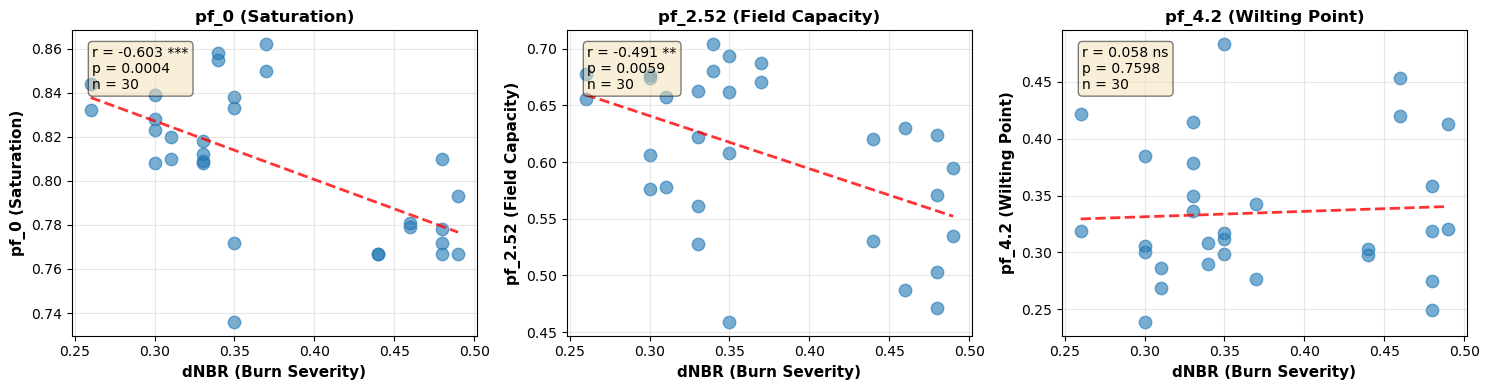

In [10]:
# Scatter plots for each pF parameter vs burn severity
fig, axes = plt.subplots(1, len(PF_COLUMNS), figsize=(15, 4))

for ax, pf_col in zip(axes, PF_COLUMNS):
    label = PF_LABELS[pf_col]
    valid_data, stats = compute_correlation_stats(merge_result, NBR_COLUMN, pf_col)

    ax.scatter(valid_data[NBR_COLUMN], valid_data[pf_col], alpha=0.6, s=80)

    if len(valid_data) >= 2 and valid_data[NBR_COLUMN].nunique() >= 2:
        trend_coefficients = np.polyfit(valid_data[NBR_COLUMN], valid_data[pf_col], 1)
        trend = np.poly1d(trend_coefficients)
        x_trend = np.linspace(valid_data[NBR_COLUMN].min(), valid_data[NBR_COLUMN].max(), 100)
        ax.plot(x_trend, trend(x_trend), 'r--', alpha=0.8, linewidth=2)

    ax.set_xlabel('dNBR (Burn Severity)', fontsize=11, fontweight='bold')
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    if stats is None:
        note = f'n = {len(valid_data)}\ninsufficient variation'
    else:
        note = (
            f"r = {stats['Pearson_r']:.3f} {significance_label(stats['Pearson_p'])}\n"
            f"p = {stats['Pearson_p']:.4f}\n"
            f"n = {stats['n_samples']}"
        )

    ax.text(
        0.05,
        0.95,
        note,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    )

plt.tight_layout()
save_figure(fig, 'correlation_pf_vs_dnbr.png')
plt.show()


SITE COMPARISON: dNBR vs WATER RETENTION PARAMETERS
Llaviuco: merged data shape = (18, 15)
Yanasacha: merged data shape = (30, 15)

--------------------------------------------------------------------------------
pf_0:
--------------------------------------------------------------------------------
Llaviuco: r = 0.5204, p = 0.1231, n = 10 (POSITIVE, ns)
Yanasacha: r = -0.5581, p = 0.0106, n = 20 (NEGATIVE, *)

--------------------------------------------------------------------------------
pf_2.52:
--------------------------------------------------------------------------------
Llaviuco: r = 0.3753, p = 0.2853, n = 10 (POSITIVE, ns)
Yanasacha: r = -0.3516, p = 0.1284, n = 20 (NEGATIVE, ns)

--------------------------------------------------------------------------------
pf_4.2:
--------------------------------------------------------------------------------
Llaviuco: r = -0.3517, p = 0.3190, n = 10 (NEGATIVE, ns)
Yanasacha: r = -0.0321, p = 0.8931, n = 20 (NEGATIVE, ns)
Visualization 

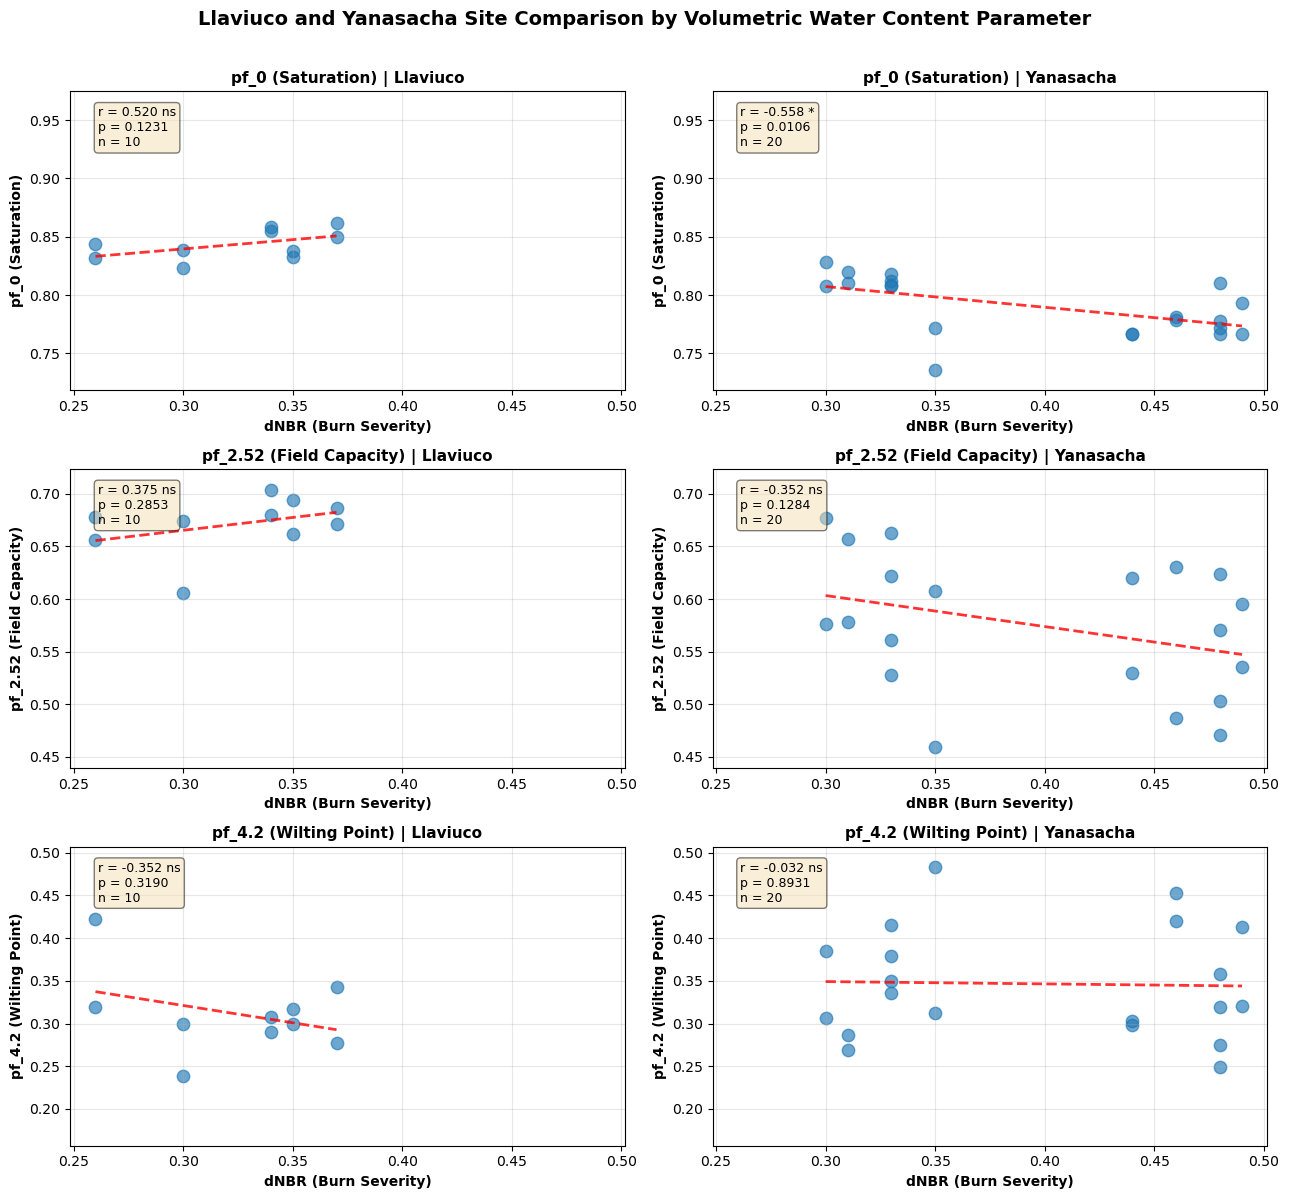

In [11]:
# Per-site correlation analysis with side-by-side site comparison per parameter
def compute_axis_limits(merged_by_site, x_col, y_cols):
    combined = pd.concat(list(merged_by_site.values()), ignore_index=True)
    x_values = combined[x_col].dropna()
    x_padding = max((x_values.max() - x_values.min()) * 0.05, 0.01)

    limits = {
        'x': (x_values.min() - x_padding, x_values.max() + x_padding),
        'y': {}
    }

    for y_col in y_cols:
        y_values = combined[y_col].dropna()
        y_padding = max((y_values.max() - y_values.min()) * 0.08, 0.01)
        limits['y'][y_col] = (y_values.min() - y_padding, y_values.max() + y_padding)

    return limits


site_data = {
    'Llaviuco': sites_llaviuco,
    'Yanasacha': sites_yanasacha
}

merged_by_site = {
    site_name: site_df.merge(
        vwc_data,
        left_on='Reference',
        right_on='site_reference',
        how='inner'
    )
    for site_name, site_df in site_data.items()
}

axis_limits = compute_axis_limits(merged_by_site, NBR_COLUMN, PF_COLUMNS)
site_correlations_by_site = {'Llaviuco': {}, 'Yanasacha': {}}

print('\n' + '=' * 80)
print('SITE COMPARISON: dNBR vs WATER RETENTION PARAMETERS')
print('=' * 80)
for site_name, site_merge in merged_by_site.items():
    print(f"{site_name}: merged data shape = {site_merge.shape}")

fig, axes = plt.subplots(3, 2, figsize=(13, 12), sharex=False)
site_order = ['Llaviuco', 'Yanasacha']

for row, pf_col in enumerate(PF_COLUMNS):
    label = PF_LABELS[pf_col]
    pf_name = pf_col.strip()
    print('\n' + '-' * 80)
    print(f'{pf_name}:')
    print('-' * 80)

    for col, site_name in enumerate(site_order):
        ax = axes[row, col]
        site_merge = merged_by_site[site_name]
        valid_data, stats = compute_correlation_stats(site_merge, NBR_COLUMN, pf_col)

        ax.scatter(valid_data[NBR_COLUMN], valid_data[pf_col], alpha=0.65, s=80)
        ax.set_title(f'{label} | {site_name}', fontsize=11, fontweight='bold')
        ax.set_xlabel('dNBR (Burn Severity)', fontsize=10, fontweight='bold')
        ax.set_ylabel(label, fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(axis_limits['x'])
        ax.set_ylim(axis_limits['y'][pf_col])

        if len(valid_data) >= 2 and valid_data[NBR_COLUMN].nunique() >= 2:
            trend_coefficients = np.polyfit(valid_data[NBR_COLUMN], valid_data[pf_col], 1)
            trend = np.poly1d(trend_coefficients)
            x_trend = np.linspace(valid_data[NBR_COLUMN].min(), valid_data[NBR_COLUMN].max(), 100)
            ax.plot(x_trend, trend(x_trend), 'r--', alpha=0.8, linewidth=2)

        if stats is None:
            print(f"{site_name}: insufficient variation (n = {len(valid_data)})")
            ax.text(
                0.05,
                0.95,
                f'n = {len(valid_data)}\ninsufficient variation',
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            )
            continue

        site_correlations_by_site[site_name][pf_name] = stats
        direction = 'POSITIVE' if stats['Pearson_r'] > 0 else 'NEGATIVE'
        print(
            f"{site_name}: r = {stats['Pearson_r']:.4f}, "
            f"p = {stats['Pearson_p']:.4f}, n = {stats['n_samples']} "
            f"({direction}, {significance_label(stats['Pearson_p'])})"
        )

        ax.text(
            0.05,
            0.95,
            f"r = {stats['Pearson_r']:.3f} {significance_label(stats['Pearson_p'])}\n"
            f"p = {stats['Pearson_p']:.4f}\n"
            f"n = {stats['n_samples']}",
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        )

plt.suptitle(
    'Llaviuco and Yanasacha Site Comparison by Volumetric Water Content Parameter',
    fontsize=14,
    fontweight='bold',
    y=0.995
 )
plt.tight_layout(rect=[0, 0, 1, 0.985])
save_figure(fig, 'correlation_pf_vs_dnbr_site_comparison.png')
plt.show()

llaviuco_merge_result = merged_by_site['Llaviuco']
yanasacha_merge_result = merged_by_site['Yanasacha']
llaviuco_correlations = site_correlations_by_site['Llaviuco']
yanasacha_correlations = site_correlations_by_site['Yanasacha']

## Summary: Site-Specific Impact of Soil Burning on Water Content

### Llaviuco

The Llaviuco subset showed **no statistically significant relationships** between burn severity (`dNBR`) and the three soil water retention parameters.

- **pf_0 (Saturation):** positive trend, but not significant (`r = 0.520`, `p = 0.123`, `n = 10`)
- **pf_2.52 (Field Capacity):** weak positive trend, not significant (`r = 0.375`, `p = 0.285`, `n = 10`)
- **pf_4.2 (Wilting Point):** weak negative trend, not significant (`r = -0.352`, `p = 0.319`, `n = 10`)

**Interpretation:** In Llaviuco, the available data do not provide strong evidence that increasing burn severity consistently changed soil water retention. The trends may reflect local variability and the relatively small sample size rather than a stable site-level effect.

### Yanasacha

The Yanasacha subset showed a **significant negative relationship at saturation**, indicating that more severely burned soils held less water under saturated conditions.

- **pf_0 (Saturation):** significant negative correlation (`r = -0.558`, `p = 0.0106`, `n = 20`)
- **pf_2.52 (Field Capacity):** negative trend, but not significant (`r = -0.352`, `p = 0.128`, `n = 20`)
- **pf_4.2 (Wilting Point):** essentially no relationship (`r = -0.032`, `p = 0.893`, `n = 20`)

**Interpretation:** In Yanasacha, burn severity appears to reduce the soil's capacity to retain water at saturation, while effects on field capacity and wilting point are weaker or absent.

### Overall Comparison

The site-specific analysis suggests that the combined pattern in the full dataset is driven more strongly by **Yanasacha** than by **Llaviuco**. In practical terms:

- The clearest burn-related impact is a reduction in **saturation water content** at Yanasacha
- **Field capacity** shows a similar direction in Yanasacha, but the evidence is not yet strong enough to confirm a significant effect
- **Llaviuco** does not show significant site-level correlations in this analysis
- The effect of burning on **wilting point** appears limited at both sites

## Summary: Impact of Soil Burning on Water Content

### Key Findings:

1. **Water at Saturation (pf_0)**: **Strong Negative Correlation (r = -0.603, p < 0.001)**
   - Burned soils hold significantly less water at saturation
   - Higher burn severity → Lower saturation water content
   - This suggests structural damage to the soil that reduces water-holding capacity

2. **Water at Field Capacity (pf_2.52)**: **Moderate Negative Correlation (r = -0.491, p < 0.010)**
   - Burned soils retain less water available for plant use at field capacity
   - This practical water availability is reduced by soil burning
   - Important for post-fire vegetation recovery and water availability

3. **Water at Wilting Point (pf_4.2)**: **No Significant Correlation (r = 0.058, p = 0.760)**
   - Water tightly bound to soil particles is essentially unaffected
   - Burning doesn't significantly impact the residual water at wilting point

### Interpretation:

**Yes, the burning of soil significantly impacts water content**, particularly:
- The accessible water (saturation and field capacity) is severely reduced
- The effect is strongest at saturation, suggesting structural damage to soil porosity
- Burned soils have difficulty retaining water, which has implications for post-fire hydrological function and vegetation recovery

### Physical Mechanism:

Soil burning likely causes:
- Destruction of soil aggregate structure
- Reduction in large pores needed for water drainage and retention
- Increased hydrophobicity (water-repellency) in some soil types
- Overall reduction in soil porosity and water-holding capacity

In [11]:
print("="*70)
print("ANALYSIS DATA COMPOSITION CHECK")
print("="*70)

# Check the merged data
print(f"\nTotal merged records (all sites x soil depths): {len(merge_result)}")

# Unique sites in merged data  
unique_sites = merge_result['Reference'].unique()
print(f"\nUnique sites in merged data: {sorted(unique_sites)}")

# Check dNBR availability by site
print("\n" + "-"*70)
print("dNBR VALUES BY SITE TYPE:")
print("-"*70)

# Identify site types
llaviuco_prefix = ['LR', 'LB']
yanasacha_burned = ['YL', 'YH', 'YR']

for site in sorted(unique_sites):
    nbr_vals = merge_result[merge_result['Reference'] == site]['dNBR'].unique()
    n_records = len(merge_result[merge_result['Reference'] == site])
    
    # Determine site type
    if any(site.startswith(prefix) for prefix in llaviuco_prefix):
        site_type = "Llaviuco"
        if site.startswith('LR'):
            burn_type = "Reference (unburned)"
        else:
            burn_type = "Burned"
    elif any(site.startswith(prefix) for prefix in yanasacha_burned):
        site_type = "Yanasacha"
        if site.startswith('YR'):
            burn_type = "Reference (unburned)"
        elif site.startswith('YL'):
            burn_type = "Low elev burned"
        else:
            burn_type = "High elev burned"
    
    nbr_str = f"{nbr_vals[0]:.4f}" if not pd.isna(nbr_vals[0]) else "NA"
    print(f"{site:4s} ({site_type:10s} - {burn_type:25s}): dNBR = {nbr_str:>8s} | {n_records} records")

# Summary statistics
print("\n" + "-"*70)
print("SUMMARY:")
print("-"*70)
valid_nbr = merge_result[merge_result['dNBR'].notna()]
na_nbr = merge_result[merge_result['dNBR'].isna()]

print(f"Records WITH dNBR values:    {len(valid_nbr)} ({100*len(valid_nbr)/len(merge_result):.1f}%)")
print(f"Records WITHOUT dNBR values: {len(na_nbr)} ({100*len(na_nbr)/len(merge_result):.1f}%)")

print(f"\n✓ Burned sites included in analysis:    {len(valid_nbr)} samples")
print(f"✗ Reference sites EXCLUDED from analysis: {len(na_nbr)} samples (NA dNBR)")

ANALYSIS DATA COMPOSITION CHECK

Total merged records (all sites x soil depths): 48

Unique sites in merged data: ['LB1', 'LB2', 'LB3', 'LB4', 'LB5', 'LR1', 'LR2', 'LR3', 'LR4', 'YH1', 'YH2', 'YH3', 'YH4', 'YH5', 'YL1', 'YL2', 'YL3', 'YL4', 'YL5', 'YR1', 'YR2', 'YR3', 'YR4', 'YR5']

----------------------------------------------------------------------
dNBR VALUES BY SITE TYPE:
----------------------------------------------------------------------
LB1  (Llaviuco   - Burned                   ): dNBR =   0.3000 | 2 records
LB2  (Llaviuco   - Burned                   ): dNBR =   0.3400 | 2 records
LB3  (Llaviuco   - Burned                   ): dNBR =   0.2600 | 2 records
LB4  (Llaviuco   - Burned                   ): dNBR =   0.3700 | 2 records
LB5  (Llaviuco   - Burned                   ): dNBR =   0.3500 | 2 records
LR1  (Llaviuco   - Reference (unburned)     ): dNBR =       NA | 2 records
LR2  (Llaviuco   - Reference (unburned)     ): dNBR =       NA | 2 records
LR3  (Llaviuco   - Refe

In [12]:
# Create a cleaned CSV with only burned sites
print("=" * 70)
print("CREATING CLEANED DATASET: BURNED SITES ONLY")
print("=" * 70)

burned_llaviuco = sites_llaviuco[sites_llaviuco[NBR_COLUMN].notna()].copy()
burned_yanasacha = sites_yanasacha[sites_yanasacha[NBR_COLUMN].notna()].copy()
burned_sites_combined = pd.concat([burned_llaviuco, burned_yanasacha], ignore_index=True)
burned_sites_combined = burned_sites_combined.sort_values('Reference')

print(f"\nBurned sites from Llaviuco: {len(burned_llaviuco)} sites")
print(f"  {burned_llaviuco['Reference'].tolist()}")

print(f"\nBurned sites from Yanasacha: {len(burned_yanasacha)} sites")
print(f"  {burned_yanasacha['Reference'].tolist()}")

print(f"\nTotal burned sites: {len(burned_sites_combined)}")
print(f"\n{burned_sites_combined}")

output_file = DATA_DIR / 'sites_burned_only.CSV'
burned_sites_combined.to_csv(output_file, index=False)
print(f"\nSaved to: {output_file}")

CREATING CLEANED DATASET: BURNED SITES ONLY

Burned sites from Llaviuco: 5 sites
  ['LB1', 'LB2', 'LB3', 'LB4', 'LB5']

Burned sites from Yanasacha: 10 sites
  ['YL1', 'YL2', 'YL3', 'YL4', 'YL5', 'YH1', 'YH2', 'YH3', 'YH4', 'YH5']

Total burned sites: 15

   Reference      Lat       Lon  Elevation        Date  dNBR
0        LB1 -2.80671 -79.16022       3585  25/11/2025  0.30
1        LB2 -2.80940 -79.16162       3769  25/11/2025  0.34
2        LB3 -2.81504 -79.15846       3742  25/11/2025  0.26
3        LB4 -2.81688 -79.15447       3669  25/11/2025  0.37
4        LB5 -2.81943 -79.15286       3638  25/11/2025  0.35
10       YH1 -2.94318 -79.20680       3665  26/11/2025  0.46
11       YH2 -2.94395 -79.20752       3639  26/11/2025  0.49
12       YH3 -2.94224 -79.20681       3615  26/11/2025  0.44
13       YH4 -2.94117 -79.20705       3556  26/11/2025  0.48
14       YH5 -2.94126 -79.20765       3526  26/11/2025  0.48
5        YL1 -2.94405 -79.19796       3626  27/11/2025  0.31
6        YL2

In [13]:
# Correlation analysis for Available Water Capacity (AWC)
# AWC = theta_FC - theta_PWP = pf_2.52 - pf_4.2
awc_df = merge_result.copy()
awc_df['AWC'] = awc_df[' pf_2.52'] - awc_df[' pf_4.2']
awc_valid = awc_df[['Reference', NBR_COLUMN, 'AWC']].dropna()

print('=' * 70)
print('CORRELATION ANALYSIS: AWC vs dNBR')
print('=' * 70)
print(f"Valid samples: {len(awc_valid)}")

if len(awc_valid) > 2:
    pearson_r, pearson_p = pearsonr(awc_valid[NBR_COLUMN], awc_valid['AWC'])
    spearman_r, spearman_p = spearmanr(awc_valid[NBR_COLUMN], awc_valid['AWC'])

    print(f"Pearson r:  {pearson_r:.4f} (p-value: {pearson_p:.4f})")
    print(f"Spearman ρ: {spearman_r:.4f} (p-value: {spearman_p:.4f})")

    direction = 'POSITIVE' if pearson_r > 0 else 'NEGATIVE'
    print(f"Result: {direction} correlation {significance_label(pearson_p)}")

    print('\nAWC by site (mean):')
    print(awc_valid.groupby('Reference')['AWC'].mean().sort_index())
else:
    print('Not enough valid samples for correlation analysis.')

CORRELATION ANALYSIS: AWC vs dNBR
Valid samples: 30
Pearson r:  -0.4332 (p-value: 0.0168)
Spearman ρ: -0.3833 (p-value: 0.0365)
Result: NEGATIVE correlation *

AWC by site (mean):
Reference
LB1    0.3705
LB2    0.3930
LB3    0.2965
LB4    0.3690
LB5    0.3700
YH1    0.1220
YH2    0.1980
YH3    0.2745
YH4    0.2045
YH5    0.2795
YL1    0.3400
YL2    0.2295
YL3    0.1360
YL4    0.2810
YL5    0.2175
Name: AWC, dtype: float64


Visualization saved to: C:\Soilgrids\analysis\results_figures\correlation_awc_vs_dnbr.png


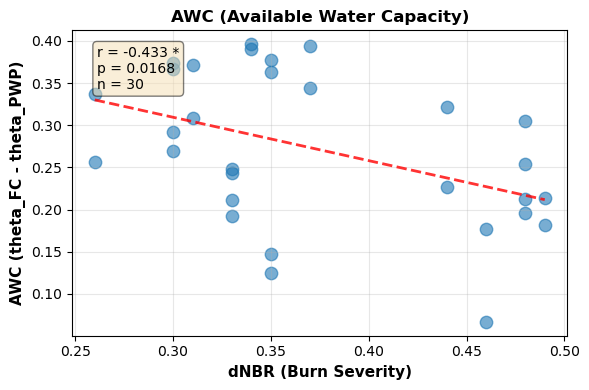

In [15]:
# Visualization: AWC vs dNBR
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(awc_valid[NBR_COLUMN], awc_valid['AWC'], alpha=0.6, s=80)

trend_coefficients = np.polyfit(awc_valid[NBR_COLUMN], awc_valid['AWC'], 1)
trend = np.poly1d(trend_coefficients)
x_trend = np.linspace(awc_valid[NBR_COLUMN].min(), awc_valid[NBR_COLUMN].max(), 100)
ax.plot(x_trend, trend(x_trend), 'r--', alpha=0.8, linewidth=2)

pearson_r, pearson_p = pearsonr(awc_valid[NBR_COLUMN], awc_valid['AWC'])

ax.set_xlabel('dNBR (Burn Severity)', fontsize=11, fontweight='bold')
ax.set_ylabel('AWC (theta_FC - theta_PWP)', fontsize=11, fontweight='bold')
ax.set_title('AWC (Available Water Capacity)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

ax.text(
    0.05,
    0.95,
    f"r = {pearson_r:.3f} {significance_label(pearson_p)}\np = {pearson_p:.4f}\nn = {len(awc_valid)}",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
 )

plt.tight_layout()
save_figure(fig, 'correlation_awc_vs_dnbr.png')
plt.show()

In [14]:
# Llaviuco only: compare burned vs reference using binary burn status
# Burn Status: Reference = 0, Burned = 1
def compare_groups(reference_values, burned_values):
    if len(reference_values) > 1 and len(burned_values) > 1:
        t_stat, t_p = ttest_ind(burned_values, reference_values, equal_var=False, nan_policy='omit')
        u_stat, u_p = mannwhitneyu(burned_values, reference_values, alternative='two-sided')
        return t_stat, t_p, u_stat, u_p

    return np.nan, np.nan, np.nan, np.nan


llaviuco_sites = sites_llaviuco.copy()
llaviuco_sites['Burn_Status'] = llaviuco_sites['Reference'].str.startswith('LB').astype(int)

vwc_llaviuco = vwc_data[vwc_data['codigo de muestra'].str.startswith('L', na=False)].copy()
vwc_llaviuco['Reference'] = vwc_llaviuco['codigo de muestra'].str.extract(r'(L[RB]\d+)')[0]

llaviuco_merged = llaviuco_sites.merge(vwc_llaviuco, on='Reference', how='inner')

print('=' * 78)
print('LLAVIUCO: BURNED (1) vs REFERENCE (0) COMPARISON')
print('=' * 78)
print("\nBurn status mapping:")
print('Reference -> 0')
print('Burned    -> 1')
print(f"\nMerged records: {len(llaviuco_merged)}")
print(f"Unique sites in merged data: {sorted(llaviuco_merged['Reference'].dropna().unique())}")

counts = llaviuco_merged.groupby('Burn_Status')['Reference'].nunique().to_dict()
print(f"\nUnique reference sites (0): {counts.get(0, 0)}")
print(f"Unique burned sites (1):   {counts.get(1, 0)}")

print('\n' + '-' * 78)
print('GROUP COMPARISON RESULTS')
print('-' * 78)

summary_rows = []
for pf_col in PF_COLUMNS:
    reference_values = llaviuco_merged.loc[llaviuco_merged['Burn_Status'] == 0, pf_col].dropna()
    burned_values = llaviuco_merged.loc[llaviuco_merged['Burn_Status'] == 1, pf_col].dropna()
    t_stat, t_p, u_stat, u_p = compare_groups(reference_values, burned_values)

    ref_mean = reference_values.mean()
    burn_mean = burned_values.mean()

    print(f"\n{pf_col.strip()}:")
    print(f"  n_ref={len(reference_values)}, n_burned={len(burned_values)}")
    print(f"  mean_ref={ref_mean:.4f}, mean_burned={burn_mean:.4f}")
    print(f"  mean_diff (burned - ref)={burn_mean - ref_mean:.4f}")
    print(f"  Welch t-test: t={t_stat:.4f}, p={t_p:.4f}")
    print(f"  Mann-Whitney U: U={u_stat:.4f}, p={u_p:.4f}")

    summary_rows.append({
        'Variable': pf_col.strip(),
        'Mean_Ref_0': ref_mean,
        'Mean_Burned_1': burn_mean,
        'Diff_Burned_minus_Ref': burn_mean - ref_mean,
        'Welch_t_pvalue': t_p
    })

llaviuco_pf_comparison = pd.DataFrame(summary_rows)
print('\n' + '-' * 78)
print('SUMMARY TABLE')
print('-' * 78)
print(llaviuco_pf_comparison)

LLAVIUCO: BURNED (1) vs REFERENCE (0) COMPARISON

Burn status mapping:
Reference -> 0
Burned    -> 1

Merged records: 18
Unique sites in merged data: ['LB1', 'LB2', 'LB3', 'LB4', 'LB5', 'LR1', 'LR2', 'LR3', 'LR4']

Unique reference sites (0): 4
Unique burned sites (1):   5

------------------------------------------------------------------------------
GROUP COMPARISON RESULTS
------------------------------------------------------------------------------

pf_0:
  n_ref=8, n_burned=10
  mean_ref=0.8177, mean_burned=0.8434
  mean_diff (burned - ref)=0.0256
  Welch t-test: t=2.2877, p=0.0478
  Mann-Whitney U: U=64.5000, p=0.0329

pf_2.52:
  n_ref=8, n_burned=10
  mean_ref=0.6583, mean_burned=0.6712
  mean_diff (burned - ref)=0.0130
  Welch t-test: t=1.0702, p=0.3007
  Mann-Whitney U: U=53.0000, p=0.2657

pf_4.2:
  n_ref=8, n_burned=10
  mean_ref=0.3413, mean_burned=0.3114
  mean_diff (burned - ref)=-0.0299
  Welch t-test: t=-1.7056, p=0.1100
  Mann-Whitney U: U=17.5000, p=0.0505

---------

Visualization saved to: C:\Soilgrids\analysis\results_figures\site_comparison_burned_vs_reference_pf_boxplots.png


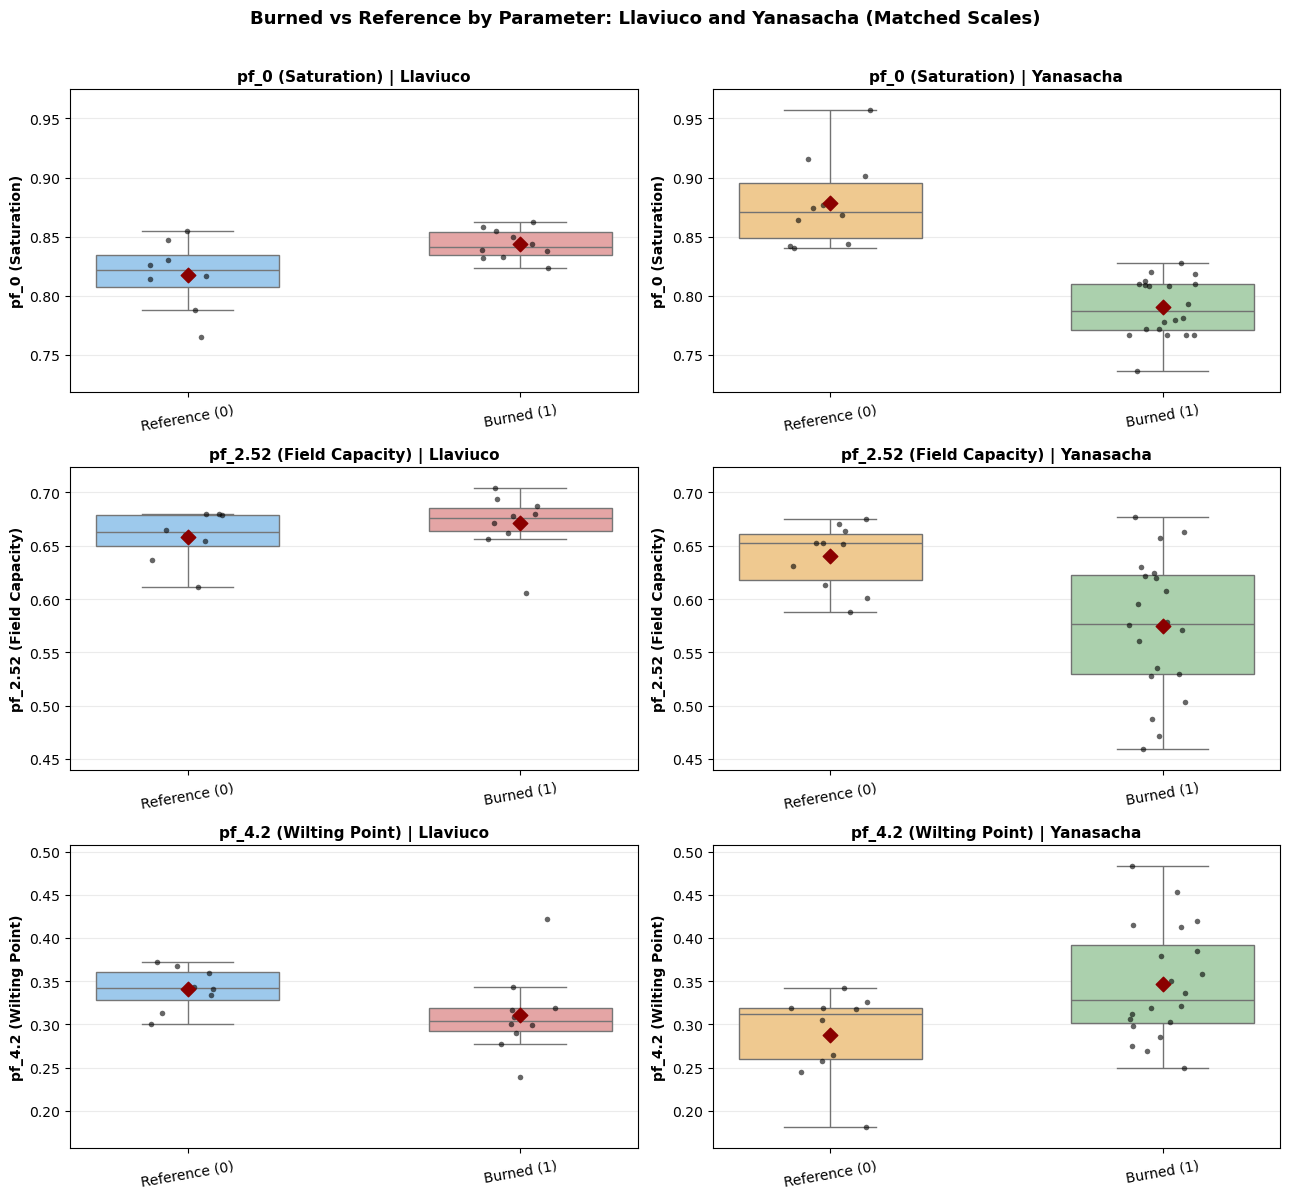

In [16]:
# Side-by-side boxplots by parameter: Llaviuco vs Yanasacha (matched y-axes)
vwc_yanasacha = vwc_data[vwc_data['codigo de muestra'].str.startswith('Y', na=False)].copy()
vwc_yanasacha['Reference'] = vwc_yanasacha['codigo de muestra'].str.extract(r'(Y[LRH]\d+)')[0]

yanasacha_sites = sites_yanasacha.copy()
yanasacha_sites['Burn_Status'] = yanasacha_sites['Reference'].str.startswith(('YL', 'YH')).astype(int)
yanasacha_merged = yanasacha_sites.merge(vwc_yanasacha, on='Reference', how='inner')

def create_site_comparison_boxplots(llaviuco_df, yanasacha_df):
    ll_plot = llaviuco_df.copy()
    ll_plot['Burn_Label'] = ll_plot['Burn_Status'].map({0: 'Reference (0)', 1: 'Burned (1)'})
    ll_plot['Site'] = 'Llaviuco'

    ya_plot = yanasacha_df.copy()
    ya_plot['Burn_Label'] = ya_plot['Burn_Status'].map({0: 'Reference (0)', 1: 'Burned (1)'})
    ya_plot['Site'] = 'Yanasacha'

    combined_plot = pd.concat([ll_plot, ya_plot], ignore_index=True)

    y_limits = {}
    for pf_col in PF_COLUMNS:
        values = combined_plot[pf_col].dropna()
        padding = max((values.max() - values.min()) * 0.08, 0.01)
        y_limits[pf_col] = (values.min() - padding, values.max() + padding)

    fig, axes = plt.subplots(3, 2, figsize=(13, 12), sharex=False)
    site_order = ['Llaviuco', 'Yanasacha']
    palettes = {
        'Llaviuco': ['#90CAF9', '#EF9A9A'],
        'Yanasacha': ['#A5D6A7', '#FFCC80']
    }

    for row, pf_col in enumerate(PF_COLUMNS):
        title = PF_LABELS[pf_col]
        for col_idx, site_name in enumerate(site_order):
            ax = axes[row, col_idx]
            site_df = combined_plot[combined_plot['Site'] == site_name]

            sns.boxplot(
                data=site_df,
                x='Burn_Label',
                y=pf_col,
                hue='Burn_Label',
                ax=ax,
                width=0.55,
                showfliers=False,
                palette=palettes[site_name],
                order=['Reference (0)', 'Burned (1)'],
                legend=False
            )
            sns.stripplot(
                data=site_df,
                x='Burn_Label',
                y=pf_col,
                ax=ax,
                color='black',
                alpha=0.6,
                jitter=0.12,
                size=4,
                order=['Reference (0)', 'Burned (1)']
            )

            means = site_df.groupby('Burn_Label')[pf_col].mean()
            for xpos, burn_label in enumerate(['Reference (0)', 'Burned (1)']):
                if burn_label in means.index:
                    ax.scatter(xpos, means[burn_label], color='darkred', s=55, marker='D', zorder=5)

            ax.set_ylim(y_limits[pf_col])
            ax.set_title(f'{title} | {site_name}', fontsize=11, fontweight='bold')
            ax.set_xlabel('')
            ax.set_ylabel(title, fontsize=10, fontweight='bold')
            ax.grid(True, axis='y', alpha=0.25)
            ax.tick_params(axis='x', rotation=10)

    plt.suptitle(
        'Burned vs Reference by Parameter: Llaviuco and Yanasacha (Matched Scales)',
        fontsize=13,
        fontweight='bold',
        y=0.995
    )
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    save_figure(fig, 'site_comparison_burned_vs_reference_pf_boxplots.png')
    plt.show()

create_site_comparison_boxplots(llaviuco_merged, yanasacha_merged)